# STEP 1: Data Loading & Exploratory Data Analysis (EDA)
# Cyberbullying Type Detector

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\XPRISTO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\XPRISTO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\XPRISTO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# 1. LOAD DATASET
# Dataset: Cyberbullying Classification (Kaggle)
# Download from: https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification

df = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\cyberbullying_tweets.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# Rename columns for clarity
df.columns = ['tweet_text', 'cyberbullying_type']

DATASET OVERVIEW
Shape       : (47692, 2)
Columns     : ['tweet_text', 'cyberbullying_type']

First 5 rows:
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying



CLASS DISTRIBUTION
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


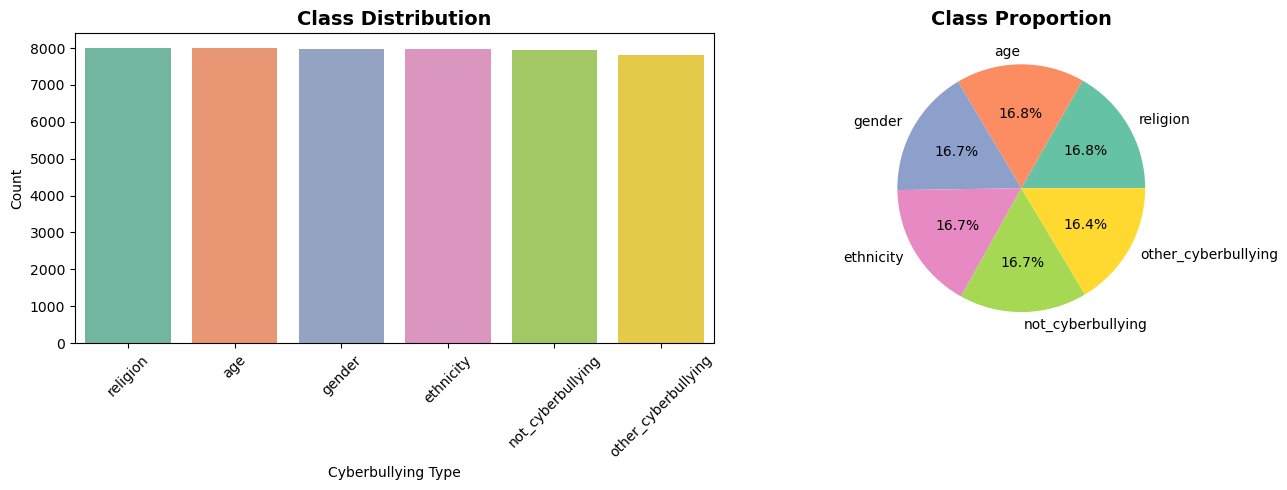

Saved: class_distribution.png


In [3]:
# 2. CLASS DISTRIBUTION
print("\n" + "=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
class_counts = df['cyberbullying_type'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cyberbullying Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\class_distribution.png', dpi=150)
plt.show()
print("Saved: class_distribution.png")


TEXT LENGTH STATISTICS
       text_length  word_count  char_count
count     47692.00    47692.00    47692.00
mean        136.25       23.70      113.52
std          85.23       15.43       70.57
min           1.00        1.00        1.00
25%          78.00       13.00       65.00
50%         124.00       20.00      103.00
75%         180.00       32.00      148.00
max        5018.00      790.00     4282.00


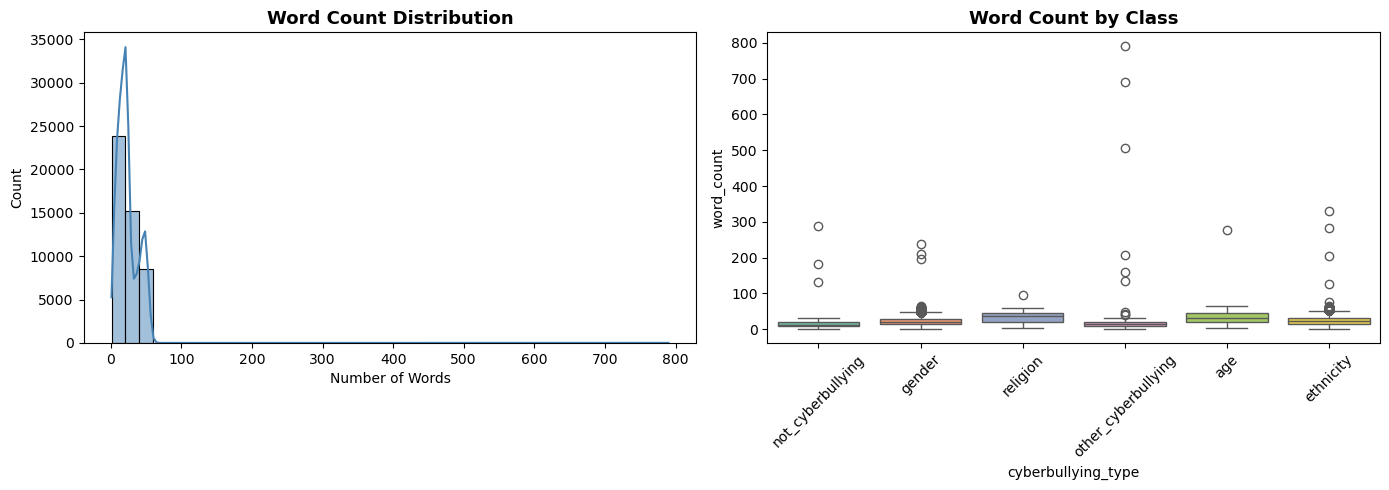

Saved: text_length_analysis.png


In [4]:
# 3. TEXT LENGTH ANALYSIS
df['text_length']  = df['tweet_text'].apply(len)
df['word_count']   = df['tweet_text'].apply(lambda x: len(str(x).split()))
df['char_count']   = df['tweet_text'].apply(lambda x: len(str(x).replace(' ', '')))

print("\n" + "=" * 50)
print("TEXT LENGTH STATISTICS")
print("=" * 50)
print(df[['text_length', 'word_count', 'char_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['word_count'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')

sns.boxplot(data=df, x='cyberbullying_type', y='word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Word Count by Class', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\text_length_analysis.png', dpi=150)
plt.show()
print("Saved: text_length_analysis.png")

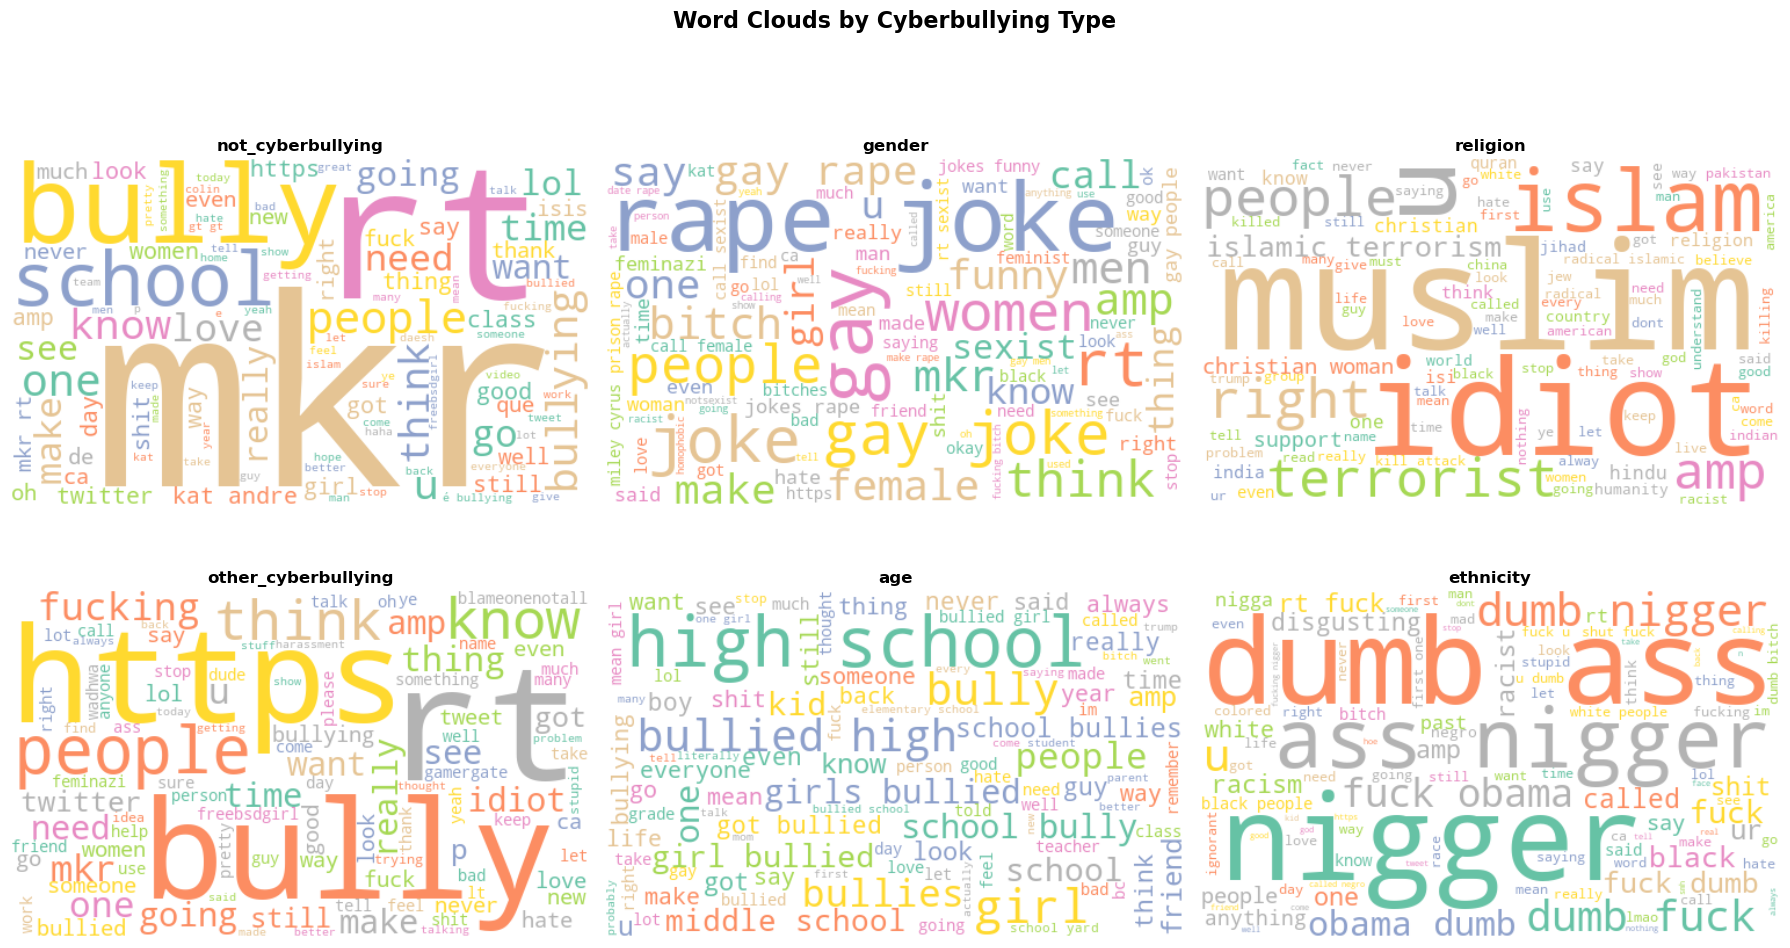

Saved: wordclouds.png


In [5]:
# 4. WORD CLOUDS PER CLASS
stop_words = set(stopwords.words('english'))
classes = df['cyberbullying_type'].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, label in enumerate(classes):
    text = ' '.join(df[df['cyberbullying_type'] == label]['tweet_text'].astype(str))
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    clean_text = ' '.join(filtered)

    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap='Set2', max_words=100).generate(clean_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{label}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Hide extra subplot if classes < 6
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Word Clouds by Cyberbullying Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wordclouds.png")

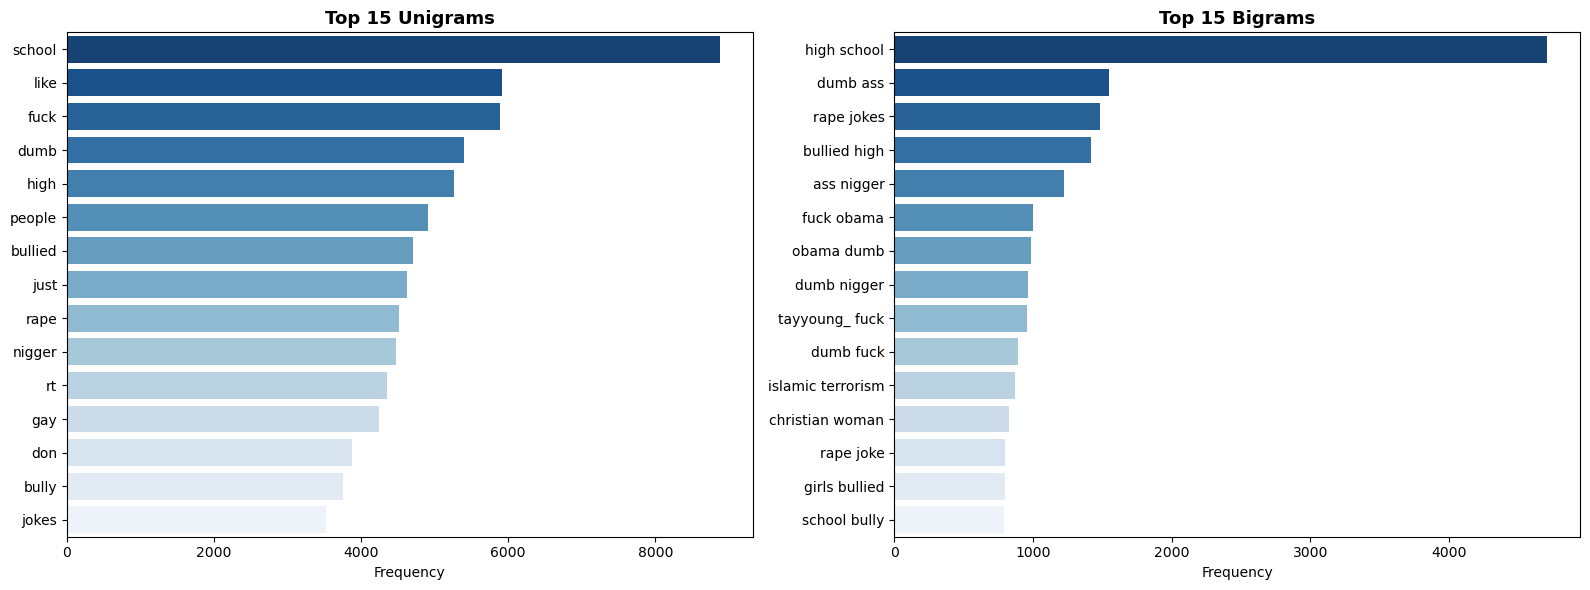

Saved: ngrams.png


In [6]:
# 5. TOP N-GRAMS
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, n in enumerate([1, 2]):
    top_ngrams = get_top_ngrams(df['tweet_text'].astype(str), n=n, top_k=15)
    words, freqs = zip(*top_ngrams)
    sns.barplot(x=list(freqs), y=list(words), ax=axes[idx], palette='Blues_r')
    axes[idx].set_title(f'Top {15} {"Unigrams" if n==1 else "Bigrams"}',
                        fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\ngrams.png', dpi=150)
plt.show()
print("Saved: ngrams.png")

In [7]:
# 6. SAVE CLEANED DATA
df.to_csv(r'C:\Users\XPRISTO\Desktop\NLP\cyberbullying_eda.csv', index=False)
print("\n EDA complete. Data saved to cyberbullying_eda.csv")
print(f"   Total samples : {len(df)}")
print(f"   Classes       : {list(df['cyberbullying_type'].unique())}")
print(f"   Missing values: {df.isnull().sum().sum()}")


 EDA complete. Data saved to cyberbullying_eda.csv
   Total samples : 47692
   Classes       : ['not_cyberbullying', 'gender', 'religion', 'other_cyberbullying', 'age', 'ethnicity']
   Missing values: 0
